# Проектирование A/B тестирования

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

## 1. Постановка задачи эксперимента

A/B тестирование — это экспериментальный метод проверки гипотез, при котором пользователи случайно разделяются на группы:

* **Контрольная группа (A)** — текущая версия продукта
* **Тестовая группа (B)** — новая версия

Цель — определить, влияет ли изменение на ключевую метрику.

Примеры метрик:

* Conversion Rate
* Average Revenue per User (ARPU)
* Retention
* CTR

In [2]:
# базовые параметры эксперимента

alpha = 0.05          # уровень значимости
power = 0.8           # мощность теста
baseline = 0.10       # базовая конверсия
mde = 0.02            # минимальный детектируемый эффект

print("alpha:", alpha)
print("power:", power)
print("baseline:", baseline)
print("MDE:", mde)

alpha: 0.05
power: 0.8
baseline: 0.1
MDE: 0.02


# 2. Формулировка статистических гипотез

Перед запуском теста необходимо сформулировать гипотезы.

Нулевая гипотеза:

$$
H_0: \mu_A = \mu_B
$$

Альтернативная гипотеза:

$$
H_1: \mu_A \neq \mu_B
$$

где:

* $ \mu_A $ — значение метрики в контроле
* $ \mu_B $ — значение метрики в эксперименте

Если вероятность наблюдать полученные данные при $H_0$ меньше уровня значимости $ \alpha $, мы отвергаем нулевую гипотезу.

# 3. Ошибки в статистических тестах

### Ошибка первого рода

$$
P(\text{reject } H_0 | H_0 \text{ true}) = \alpha
$$

Это вероятность обнаружить эффект, когда его нет.

Обычно:

$$
\alpha = 0.05
$$

### Ошибка второго рода

$$
\beta = P(\text{fail to reject } H_0 | H_1 \text{ true})
$$

Это вероятность **не обнаружить реальный эффект**.

# 4. Мощность теста

Мощность теста определяется как:

$$
Power = 1 - \beta
$$

Она показывает вероятность обнаружить реальный эффект.

Типичные значения:

* 0.8
* 0.9


# 5. Минимальный детектируемый эффект (MDE)

Перед запуском нужно определить **MDE (Minimum Detectable Effect)**.

Это минимальное изменение метрики, которое мы хотим обнаружить.

Например:

* текущая конверсия: 10%
* MDE: +2%

$$
MDE = 0.02
$$

Тогда:

$$
p_B = p_A + MDE
$$

По сути, библиотека итеративно подбирает значения в формуле:

$$
n = \frac{(z_{1-\alpha/2}+z_{1-\beta})^2*(\sigma_1^2+\sigma_2^2)}{MDE^2}
$$

In [3]:
import statsmodels.stats.api as sms

# 1. Задаем вводные данные
baseline_conv = 0.05  # Текущая конверсия 5%
n_per_group = 20000   # Размер одной группы (всего 20 000)
alpha = 0.05          # Уровень значимости
power = 0.8           # Мощность теста

# 2. Инициализируем объект для анализа мощности (Z-test для пропорций)
analysis = sms.NormalIndPower()

# 3. Рассчитываем стандартизированный размер эффекта (effect size)
effect_size = analysis.solve_power(
    nobs1=n_per_group, 
    alpha=alpha, 
    power=power, 
    ratio=1.0  # Соотношение групп 1:1
)

# 4. Переводим стандартизированный эффект в понятный MDE
# (Упрощенно: эффект * корень из дисперсии)
import numpy as np
variance = baseline_conv * (1 - baseline_conv)
mde_absolute = effect_size * np.sqrt(variance)

print(f"Абсолютный MDE: {mde_absolute:.4f} (или {mde_absolute*100:.2f} процентных пункта)")
print(f"То есть мы заметим изменение конверсии с 5% до {5 + mde_absolute*100:.2f}%")


Абсолютный MDE: 0.0061 (или 0.61 процентных пункта)
То есть мы заметим изменение конверсии с 5% до 5.61%


In [4]:
effect_size

0.028014914978909462


В итоге мы можем построить график и посмотреть, как MDE растет (падает) при определенном количестве человек и понять, какой эффект можно поймать

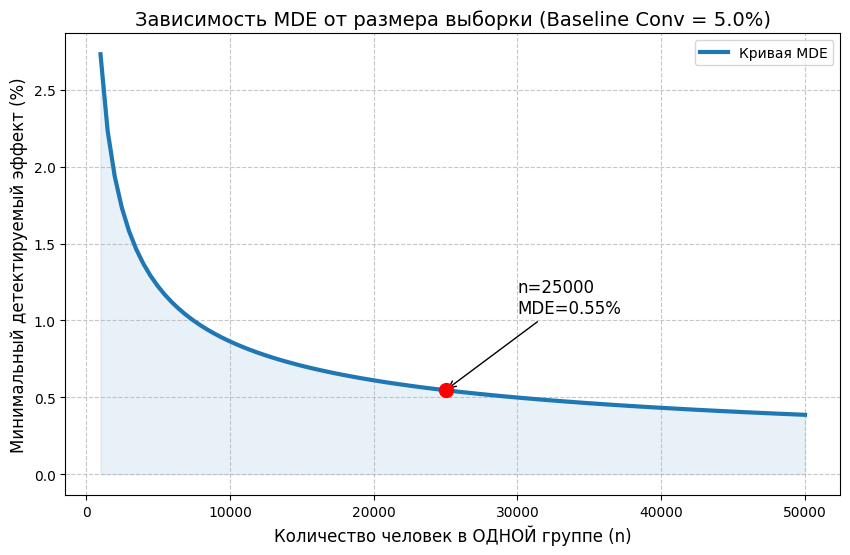

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms

def plot_mde_curve(baseline_conv=0.05, alpha=0.05, power=0.8):
    # 1. Готовим диапазон размеров выборки (от 1 000 до 50 000 человек в группе)
    n_range = np.linspace(1000, 50000, 100)
    
    # Объект для расчета мощности Z-теста для пропорций
    analysis = sms.NormalIndPower()
    
    mdes = []
    sigma = np.sqrt(baseline_conv * (1 - baseline_conv)) # Стандартное отклонение для конверсии

    # 2. Считаем MDE для каждой точки n
    for n in n_range:
        # Решаем уравнение относительно effect_size
        effect_size = analysis.solve_power(nobs1=n, alpha=alpha, power=power, ratio=1.0)
        
        # Переводим в абсолютный MDE (в процентах)
        mde_abs = effect_size * sigma * 100
        mdes.append(mde_abs)

    # 3. Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(n_range, mdes, lw=3, color='#1f77b4', label='Кривая MDE')
    plt.fill_between(n_range, mdes, color='#1f77b4', alpha=0.1)

    # Добавим точку для наглядности (например, на 20 000 чел)
    n_point = 25000
    es_point = analysis.solve_power(nobs1=n_point, alpha=alpha, power=power)
    mde_point = es_point * sigma * 100
    
    plt.scatter(n_point, mde_point, color='red', s=100, zorder=5)
    plt.annotate(f'n={n_point}\nMDE={mde_point:.2f}%', 
                 xy=(n_point, mde_point), xytext=(n_point+5000, mde_point+0.5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=12)

    # Оформление
    plt.title(f'Зависимость MDE от размера выборки (Baseline Conv = {baseline_conv*100}%)', fontsize=14)
    plt.xlabel('Количество человек в ОДНОЙ группе (n)', fontsize=12)
    plt.ylabel('Минимальный детектируемый эффект (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Запуск функции
plot_mde_curve()


# 6. Расчет размера выборки

Размер выборки зависит от:

* уровня значимости $\alpha$
* мощности теста
* дисперсии метрики
* MDE

Для конверсии используется формула:

$$
n =
\frac{
2(Z_{1-\alpha/2} + Z_{1-\beta})^2 \cdot p(1-p)
}
{MDE^2}
$$

где

* $p$ — базовая конверсия
* $Z$ — квантиль нормального распределения


In [17]:
def sample_size_proportion(p, mde, alpha=0.05, power=0.8):

    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_beta = stats.norm.ppf(power)

    n = (2 * (z_alpha + z_beta)**2 * p * (1 - p)) / (mde**2)

    return int(np.ceil(n))


sample_size = sample_size_proportion(baseline, 0.01)

print("Sample size per group:", sample_size)
print("Total users needed:", sample_size * 2)

Sample size per group: 14128
Total users needed: 28256


# 7. Пример расчета

Пусть:

* базовая конверсия (p = 0.10)
* MDE = 0.02
* $\alpha = 0.05$
* power = 0.8

Квантили:

$$
Z_{1-\alpha/2} = 1.96
$$

$$
Z_{1-\beta} = 0.84
$$

Подставим:

$$
n =
\frac{
2(1.96 + 0.84)^2 \cdot 0.1(1-0.1)
}
{0.02^2}
$$

$$
n =
\frac{
2(2.8)^2 \cdot 0.09
}
{0.0004}
$$

$$
n =
\frac{
2 \cdot 7.84 \cdot 0.09
}{0.0004}
$$

$$
n = \frac{1.4112}{0.0004}
$$

$$
n \approx 3528
$$

Таким образом необходимо:

**~3500 пользователей на группу**

# 8. Выбор экспериментальных групп

Обычно используется распределение:

$$
50% / 50%
$$

Иногда применяют:

| распределение | когда используют      |
| ------------- | --------------------- |
| 90 / 10       | рискованные изменения |
| 80 / 20       | постепенный rollout   |
| 50 / 50       | стандарт              |


# 9. Рандомизация

Главный принцип — **случайное распределение пользователей**.

Часто используется hashing:

$$
group = hash(user\_id) \mod 100
$$

пример:

```
0-49  -> control
50-99 -> treatment
```

Это гарантирует:

* случайность
* воспроизводимость
* стабильность групп


In [7]:
import hashlib

def assign_group(user_id):

    hash_value = int(hashlib.md5(str(user_id).encode()).hexdigest(), 16)

    bucket = hash_value % 100

    if bucket < 50:
        return "control"
    else:
        return "treatment"

In [8]:
users = pd.DataFrame({
    "user_id": range(1,10001)
})

users["group"] = users["user_id"].apply(assign_group)

users.groupby("group").size()

group
control      4998
treatment    5002
dtype: int64

# 10. Стратификация

Если аудитория неоднородна, применяется **stratified randomization**.

Страты могут быть:

* страна
* устройство
* новый / старый пользователь
* источник трафика

Процесс:

1. делим пользователей на страты
2. внутри каждой страты проводим рандомизацию

Например:

| страна | control | treatment |
| ------ | ------- | --------- |
| EU     | 50%     | 50%       |
| US     | 50%     | 50%       |



In [9]:
np.random.seed(42)

users = pd.DataFrame({
    "user_id": range(10000),
    "country": np.random.choice(["US","EU","ASIA"], 10000),
    "device": np.random.choice(["mobile","desktop"], 10000)
})

In [10]:
def stratified_split(df, strata_cols):

    df = df.copy()
    df["group"] = None

    for _, group_df in df.groupby(strata_cols):

        idx = group_df.index
        assignment = np.random.choice(
            ["control","treatment"],
            size=len(idx),
            p=[0.5,0.5]
        )

        df.loc[idx,"group"] = assignment

    return df


users = stratified_split(users, ["country","device"])

In [11]:
pd.crosstab(users.country, users.group)

group,control,treatment
country,,
ASIA,1619,1680
EU,1716,1631
US,1673,1681


# 11. Почему стратификация важна

Она уменьшает дисперсию оценки эффекта.

Дисперсия оценки эффекта:

$$
Var(\hat{\Delta}) =
\frac{\sigma_A^2}{n_A} +
\frac{\sigma_B^2}{n_B}
$$

Если страты сбалансированы, дисперсия меньше.

Это увеличивает **мощность теста**.

# 12. Проверки перед запуском

Перед запуском эксперимента делают несколько проверок.

### A/A тест

Проверяем систему экспериментов.

$$
H_0: \mu_A = \mu_A
$$

Если система работает правильно — различий быть не должно.

### Проверка SRM

SRM — Sample Ratio Mismatch.

Ожидаемое распределение: 50/50

Если получаем другое значит проблема:

* в логировании
* в рандомизации
* в фильтрации пользователей

Проверяется через **chi-square test**.

In [12]:
def check_srm(control, treatment, expected_ratio=0.5):

    observed = np.array([control, treatment])
    total = control + treatment

    expected = np.array([
        total * expected_ratio,
        total * (1 - expected_ratio)
    ])

    chi2, p = stats.chisquare(observed, expected)

    return chi2, p

In [18]:
control = 5200
treatment = 5200

chi2, p = check_srm(control, treatment)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 0.0
p-value: 1.0


# 14. Общий pipeline запуска A/B теста

1. Формулировка гипотезы
2. Выбор метрики
3. Определение MDE
4. Выбор $\alpha$ и power
5. Расчет размера выборки
6. Рандомизация пользователей
7. Стратификация (если нужно)
8. A/A тест
9. Проверка SRM
10. Запуск эксперимента